<a href="https://colab.research.google.com/github/castrokelly/PPGIa/blob/main/Exercicio_1_2_Insurance_Regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizagem de Máquina (Turma ME)
## PPGIa - Programa de Pós-Graduação em Informática - PUCPR - Pontifícia Universidade Católica do Paraná
Turma: PPGIa (404) 2026/02  
Professor: Alceu de Souza Britto Jr. (alceu@ppgia.pucpr.br)  
Aluno(a): 40131556 - Kelly Christine Alvarenga de Castro (christine.kelly@pucpr.edu.br)

# Exercício 1.2 — Regressão para estimativa do valor de seguro saúde

## Objetivo

Criar um modelo preditivo para estimar o valor do seguro saúde (`charges`) a partir dos atributos:

- `age`: idade do segurado;
- `sex`: gênero;
- `bmi`: índice de massa corporal;
- `children`: número de filhos;
- `smoker`: se fuma ou não;
- `region`: região onde vive.

O modelo principal será uma **Árvore de Regressão**, porque o enunciado exige uma solução **caixa branca**, isto é, facilmente explicável. Depois, compararemos seu desempenho com outros modelos monolíticos e ensembles, incluindo **SVR**, **MLP**, **Random Forest**, **Bagging**, **AdaBoost** e **Gradient Boosting**.

# 1) Conceito  

Este exercício é uma tarefa de **aprendizagem supervisionada para regressão**.

Na regressão, o atributo alvo é contínuo. Aqui, queremos aprender uma função aproximada:

\[
\hat{y} = f(X)
\]

onde:

- \(X\) representa os atributos de entrada do segurado;
- \(\hat{y}\) representa o valor estimado do seguro;
- \(y\) representa o valor real do seguro, isto é, `charges`.

A **Árvore de Regressão** divide o espaço dos atributos em regiões. Em cada folha, ela retorna um valor médio estimado para `charges`. Por isso, é mais interpretável do que modelos como MLP ou SVR.

Como a base possui atributos categóricos (`sex`, `smoker`, `region`), eles precisam ser transformados em valores numéricos. Neste notebook usaremos **One-Hot Encoding**, que cria uma coluna binária para cada categoria.

# 2) Resolução

## 2.1 Importação das bibliotecas

In [1]:
# Bibliotecas principais
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Download da base no Kaggle
import kagglehub

# Scikit-learn: divisão, pré-processamento, modelos e métricas
import sklearn
from packaging import version

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    BaggingRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Versão do scikit-learn:", sklearn.__version__)

Versão do scikit-learn: 1.6.1


## 2.2 Download da base pelo KaggleHub

O dataset será baixado diretamente do Kaggle usando:

```python
path = kagglehub.dataset_download("mirichoi0218/insurance")
```

Depois, localizaremos automaticamente o arquivo `.csv` dentro da pasta baixada.

In [2]:
# Download da versão mais recente da base insurance
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

# Procura arquivos CSV dentro do diretório retornado pelo kagglehub
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print("Arquivos CSV encontrados:", csv_files)

# Seleciona o primeiro CSV encontrado
csv_path = csv_files[0]
print("CSV selecionado:", csv_path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance
Arquivos CSV encontrados: ['/kaggle/input/insurance/insurance.csv']
CSV selecionado: /kaggle/input/insurance/insurance.csv


## 2.3 Carregamento da base

In [3]:
# Carregar o CSV em um DataFrame
df = pd.read_csv(csv_path)

# Exibir dimensões e primeiras linhas
print("Dimensão da base:", df.shape)
display(df.head())

Dimensão da base: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2.4 Inspeção inicial dos dados

In [4]:
# Informações gerais da base
print("Informações da base:")
df.info()

print("\nValores ausentes por coluna:")
print(df.isna().sum())

print("\nQuantidade de registros duplicados:", df.duplicated().sum())

Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Valores ausentes por coluna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Quantidade de registros duplicados: 1


In [5]:
# Remover duplicados - 1
antes = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
depois = df.shape[0]

print(f"Registros antes: {antes}")
print(f"Registros depois: {depois}")
print(f"Duplicados removidos: {antes - depois}")

Registros antes: 1338
Registros depois: 1337
Duplicados removidos: 1


## 2.5 Análise descritiva

In [8]:
# Estatísticas das variáveis numéricas
display(df.describe())

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# Distribuição das variáveis categóricas
categorical_features = ["sex", "smoker", "region"]

for col in categorical_features:
    print(f"\nDistribuição de {col}:")
    print(df[col].value_counts())


Distribuição de sex:
sex
male      675
female    662
Name: count, dtype: int64

Distribuição de smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

Distribuição de region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


## 2.6 Visualização da variável alvo

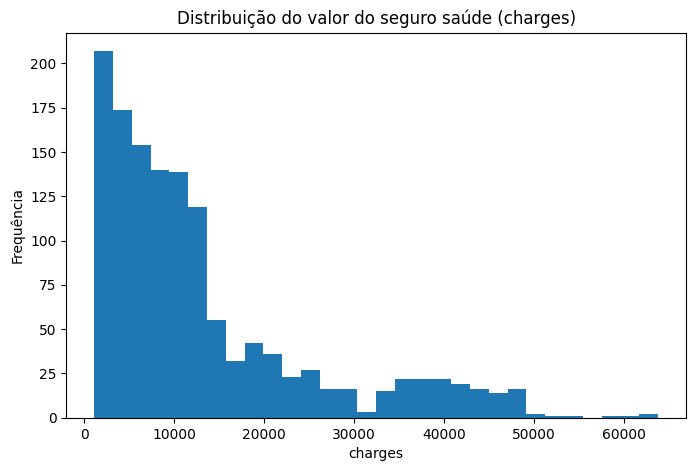

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["charges"], bins=30)
plt.title("Distribuição do valor do seguro saúde (charges)")
plt.xlabel("charges")
plt.ylabel("Frequência")
plt.show()

<Figure size 800x500 with 0 Axes>

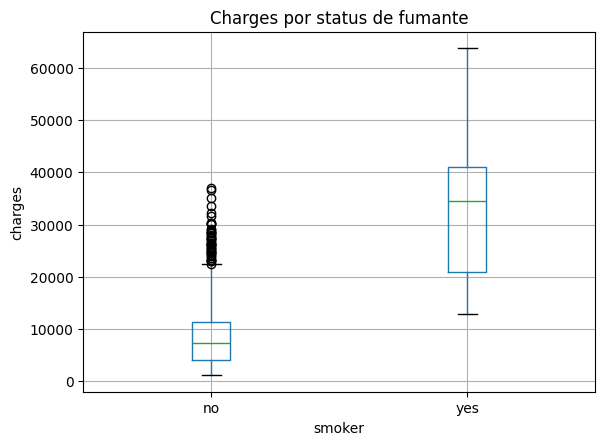

In [10]:
plt.figure(figsize=(8, 5))
df.boxplot(column="charges", by="smoker")
plt.title("Charges por status de fumante")
plt.suptitle("")
plt.xlabel("smoker")
plt.ylabel("charges")
plt.show()

**Interpretação:**

O gráfico por `smoker` mostra que a variável `smoker` é muito relevante para estimar `charges`. Segurados fumantes tendem a apresentar valores de seguro mais altos.

## 2.7 Separação dos atributos de entrada e do alvo

In [11]:
# Atributos de entrada
X = df.drop(columns=["charges"])

# Atributo alvo
y = df["charges"]

numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

print("Atributos de entrada:")
print(X.columns.tolist())

print("\nAtributo alvo:")
print("charges")

print("\nVariáveis numéricas:", numeric_features)
print("Variáveis categóricas:", categorical_features)

Atributos de entrada:
['age', 'sex', 'bmi', 'children', 'smoker', 'region']

Atributo alvo:
charges

Variáveis numéricas: ['age', 'bmi', 'children']
Variáveis categóricas: ['sex', 'smoker', 'region']


## 2.8 Divisão treino/teste

Usaremos 80% para treinamento e 20% para teste.

A base de teste será usada apenas para avaliação final.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)

Tamanho do treino: (1069, 6)
Tamanho do teste: (268, 6)


## 2.9 Pré-processamento: One-Hot Encoding e normalização

Foram usados dois pré-processadores:

1. **Pré-processador para árvores e ensembles de árvores**  
   - aplica `OneHotEncoder` nas variáveis categóricas;
   - mantém as variáveis numéricas na escala original.

2. **Pré-processador para SVR e MLP**  
   - aplica `OneHotEncoder` nas variáveis categóricas;
   - aplica `StandardScaler` nas variáveis numéricas.

A normalização é importante para modelos sensíveis à escala, como SVR e MLP.

In [13]:
# Compatibilidade com diferentes versões do scikit-learn:
# versões recentes usam sparse_output=False;
# versões antigas usam sparse=False.
def criar_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessador_arvore = ColumnTransformer(
    transformers=[
        ("cat", criar_one_hot_encoder(), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

preprocessador_escalonado = ColumnTransformer(
    transformers=[
        ("cat", criar_one_hot_encoder(), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

print("Pré-processadores criados com sucesso.")

Pré-processadores criados com sucesso.


## 2.10 Funções auxiliares de avaliação

In [14]:
def calcular_rmse(y_true, y_pred):
    """Calcula RMSE de forma compatível com diferentes versões do scikit-learn."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def avaliar_regressor(nome_modelo, modelo, X_test, y_test):
    """Avalia um modelo de regressão usando MAE, RMSE e R²."""
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = calcular_rmse(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        "Modelo": nome_modelo,
        "MAE_teste": mae,
        "RMSE_teste": rmse,
        "R2_teste": r2
    }

## 2.11 Criação dos modelos e hiperparâmetros

O modelo principal será a **Árvore de Regressão**.

Os demais modelos entram para comparação:

- SVR;
- MLP;
- Random Forest;
- Bagging com Árvores de Regressão;
- AdaBoost;
- Gradient Boosting.

In [15]:
# Compatibilidade com versões antigas e recentes do scikit-learn
usa_parametro_estimator = version.parse(sklearn.__version__) >= version.parse("1.2")

# Modelos e grades de hiperparâmetros
modelos_parametros = {}

# 1) Árvore de Regressão: modelo principal caixa branca
modelos_parametros["Árvore de Regressão"] = (
    Pipeline(steps=[
        ("preprocessador", preprocessador_arvore),
        ("modelo", DecisionTreeRegressor(random_state=42))
    ]),
    {
        "modelo__max_depth": [3, 4, 5, None],
        "modelo__min_samples_leaf": [5, 10, 20]
    }
)

# 2) SVR: sensível à escala
modelos_parametros["SVR"] = (
    Pipeline(steps=[
        ("preprocessador", preprocessador_escalonado),
        ("modelo", SVR())
    ]),
    {
        "modelo__kernel": ["linear", "rbf"],
        "modelo__C": [10, 100],
        "modelo__epsilon": [10]
    }
)

# 3) MLP: rede neural rasa/multicamadas, sensível à escala
modelos_parametros["MLP"] = (
    Pipeline(steps=[
        ("preprocessador", preprocessador_escalonado),
        ("modelo", MLPRegressor(
            max_iter=400,
            early_stopping=True,
            random_state=42
        ))
    ]),
    {
        "modelo__hidden_layer_sizes": [(100,)],
        "modelo__alpha": [0.001]
    }
)

# 4) Random Forest
modelos_parametros["Random Forest"] = (
    Pipeline(steps=[
        ("preprocessador", preprocessador_arvore),
        ("modelo", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=1
        ))
    ]),
    {
        "modelo__max_depth": [4, 6, None],
        "modelo__min_samples_leaf": [5, 10]
    }
)

# 5) Bagging com Árvore de Regressão
if usa_parametro_estimator:
    bagging_model = BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=20,
        random_state=42,
        n_jobs=1
    )
    bagging_grid = {
        "modelo__estimator__max_depth": [4, None],
        "modelo__estimator__min_samples_leaf": [5, 10]
    }
else:
    bagging_model = BaggingRegressor(
        base_estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=20,
        random_state=42,
        n_jobs=1
    )
    bagging_grid = {
        "modelo__base_estimator__max_depth": [4, None],
        "modelo__base_estimator__min_samples_leaf": [5, 10]
    }

modelos_parametros["Bagging AR"] = (
    Pipeline(steps=[
        ("preprocessador", preprocessador_arvore),
        ("modelo", bagging_model)
    ]),
    bagging_grid
)

# 6) AdaBoost com árvore rasa como estimador base
if usa_parametro_estimator:
    adaboost_model = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
        random_state=42
    )
else:
    adaboost_model = AdaBoostRegressor(
        base_estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
        random_state=42
    )

modelos_parametros["AdaBoost"] = (
    Pipeline(steps=[
        ("preprocessador", preprocessador_arvore),
        ("modelo", adaboost_model)
    ]),
    {
        "modelo__n_estimators": [50],
        "modelo__learning_rate": [0.05, 0.1, 1.0]
    }
)

# 7) Gradient Boosting
modelos_parametros["Gradient Boosting"] = (
    Pipeline(steps=[
        ("preprocessador", preprocessador_arvore),
        ("modelo", GradientBoostingRegressor(random_state=42))
    ]),
    {
        "modelo__n_estimators": [100, 200],
        "modelo__learning_rate": [0.05, 0.1],
        "modelo__max_depth": [2]
    }
)

print("Modelos configurados:")
print(list(modelos_parametros.keys()))

Modelos configurados:
['Árvore de Regressão', 'SVR', 'MLP', 'Random Forest', 'Bagging AR', 'AdaBoost', 'Gradient Boosting']


## 2.12 Treinamento com validação cruzada e GridSearchCV

Usaremos validação cruzada com 5 folds.

A métrica de seleção no `GridSearchCV` será:

```python
scoring="neg_root_mean_squared_error"
```

O scikit-learn usa o sinal negativo porque, internamente, o `GridSearchCV` maximiza a métrica. Portanto, depois vamos multiplicar por `-1` para interpretar o RMSE corretamente.

In [16]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados = []
melhores_modelos = {}

for nome, (modelo, parametros) in modelos_parametros.items():
    print(f"Treinando: {nome}")

    grid = GridSearchCV(
        estimator=modelo,
        param_grid=parametros,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=1,
        refit=True
    )

    grid.fit(X_train, y_train)

    avaliacao = avaliar_regressor(nome, grid.best_estimator_, X_test, y_test)
    avaliacao["CV_RMSE_medio"] = -grid.best_score_
    avaliacao["Melhores_parametros"] = grid.best_params_

    resultados.append(avaliacao)
    melhores_modelos[nome] = grid.best_estimator_

    print(f"  Melhor RMSE médio na validação cruzada: {-grid.best_score_:.2f}")
    print(f"  Melhores parâmetros: {grid.best_params_}")
    print()

resultados_df = pd.DataFrame(resultados)
resultados_df = resultados_df.sort_values(by="RMSE_teste")

# Reordenar colunas para facilitar leitura
resultados_df = resultados_df[[
    "Modelo",
    "CV_RMSE_medio",
    "MAE_teste",
    "RMSE_teste",
    "R2_teste",
    "Melhores_parametros"
]]

display(resultados_df)

Treinando: Árvore de Regressão
  Melhor RMSE médio na validação cruzada: 4718.06
  Melhores parâmetros: {'modelo__max_depth': 5, 'modelo__min_samples_leaf': 10}

Treinando: SVR
  Melhor RMSE médio na validação cruzada: 7803.84
  Melhores parâmetros: {'modelo__C': 100, 'modelo__epsilon': 10, 'modelo__kernel': 'linear'}

Treinando: MLP
  Melhor RMSE médio na validação cruzada: 17499.06
  Melhores parâmetros: {'modelo__alpha': 0.001, 'modelo__hidden_layer_sizes': (100,)}

Treinando: Random Forest
  Melhor RMSE médio na validação cruzada: 4554.86
  Melhores parâmetros: {'modelo__max_depth': 6, 'modelo__min_samples_leaf': 10}

Treinando: Bagging AR
  Melhor RMSE médio na validação cruzada: 4563.59
  Melhores parâmetros: {'modelo__estimator__max_depth': 4, 'modelo__estimator__min_samples_leaf': 10}

Treinando: AdaBoost
  Melhor RMSE médio na validação cruzada: 4915.64
  Melhores parâmetros: {'modelo__learning_rate': 0.05, 'modelo__n_estimators': 50}

Treinando: Gradient Boosting
  Melhor RMS

,Modelo,CV_RMSE_medio,MAE_teste,RMSE_teste,R2_teste,Melhores_parametros
4,Bagging AR,4563.586227,2439.339890,4204.237375,0.903809,"{'modelo__estimator__max_depth': 4, 'modelo__e..."
3,Random Forest,4554.858224,2422.210303,4233.155009,0.902482,"{'modelo__max_depth': 6, 'modelo__min_samples_..."
6,Gradient Boosting,4570.373733,2504.895346,4253.814660,0.901527,"{'modelo__learning_rate': 0.05, 'modelo__max_d..."
0,Árvore de Regressão,4718.064587,2503.306154,4302.953375,0.899239,"{'modelo__max_depth': 5, 'modelo__min_samples_..."
5,AdaBoost,4915.644994,3650.882810,4710.332556,0.879257,"{'modelo__learning_rate': 0.05, 'modelo__n_est..."
1,SVR,7803.836096,4305.336532,8778.534823,0.580625,"{'modelo__C': 100, 'modelo__epsilon': 10, 'mod..."
2,MLP,17499.058837,14269.598721,19681.890010,-1.108103,"{'modelo__alpha': 0.001, 'modelo__hidden_layer..."


## 2.13 Seleção do modelo principal: Árvore de Regressão

O melhor desempenho geral foi obtido pelo **Bagging com Árvores de Regressão**, pois apresentou o menor RMSE no teste e o maior R². O **Random Forest** teve o menor MAE, mas ficou muito próximo do Bagging. A **Árvore de Regressão simples** teve desempenho um pouco inferior, mas permanece como modelo principal para interpretação por ser caixa branca.

In [18]:
modelo_ar = melhores_modelos["Árvore de Regressão"]

# Previsões da Árvore de Regressão
y_pred_ar = modelo_ar.predict(X_test)

mae_ar = mean_absolute_error(y_test, y_pred_ar)
rmse_ar = calcular_rmse(y_test, y_pred_ar)
r2_ar = r2_score(y_test, y_pred_ar)

print("Desempenho da Árvore de Regressão")
print(f"MAE : {mae_ar:.2f}")
print(f"RMSE: {rmse_ar:.2f}")
print(f"R²  : {r2_ar:.4f}")

Desempenho da Árvore de Regressão
MAE : 2503.31
RMSE: 4302.95
R²  : 0.8992


## 2.14 Importância dos atributos na Árvore de Regressão

Como usamos `OneHotEncoder`, atributos categóricos viraram colunas binárias. Por exemplo:

- `smoker_no`;
- `smoker_yes`;
- `sex_female`;
- `sex_male`;
- `region_northeast`, etc.

In [19]:
# Recuperar nomes das colunas depois do One-Hot Encoding
preprocessador_treinado = modelo_ar.named_steps["preprocessador"]
modelo_arvore_treinado = modelo_ar.named_steps["modelo"]

nomes_cat = preprocessador_treinado.named_transformers_["cat"].get_feature_names_out(categorical_features)
nomes_features = list(nomes_cat) + numeric_features

importancias = pd.DataFrame({
    "atributo": nomes_features,
    "importancia": modelo_arvore_treinado.feature_importances_
}).sort_values(by="importancia", ascending=False)

display(importancias)

,atributo,importancia
2,smoker_no,0.692359
9,bmi,0.174940
8,age,0.120493
10,children,0.010428
4,region_northeast,0.001780
1,sex_male,0.000000
0,sex_female,0.000000
6,region_southeast,0.000000
5,region_northwest,0.000000
3,smoker_yes,0.000000


Interpretação: o fato de a pessoa ser fumante ou não é o principal fator para estimar `charges`, seguido por `bmi` e `age`.

Observação: a árvore pode usar `smoker_no` ou `smoker_yes`, dependendo da codificação gerada pelo `OneHotEncoder`. O significado é equivalente: o modelo está usando o status de fumante como variável principal.

## 2.15 Regras textuais da Árvore de Regressão

As regras textuais são importantes para justificar a característica caixa branca do modelo.

In [20]:
regras = export_text(
    modelo_arvore_treinado,
    feature_names=nomes_features,
    max_depth=4
)

print(regras)

|--- smoker_no <= 0.50
|   |--- bmi <= 30.01
|   |   |--- age <= 41.00
|   |   |   |--- bmi <= 24.26
|   |   |   |   |--- age <= 27.50
|   |   |   |   |   |--- value: [15224.38]
|   |   |   |   |--- age >  27.50
|   |   |   |   |   |--- value: [17344.46]
|   |   |   |--- bmi >  24.26
|   |   |   |   |--- age <= 23.50
|   |   |   |   |   |--- value: [17880.00]
|   |   |   |   |--- age >  23.50
|   |   |   |   |   |--- value: [20193.25]
|   |   |--- age >  41.00
|   |   |   |--- age <= 56.50
|   |   |   |   |--- bmi <= 25.96
|   |   |   |   |   |--- value: [23153.74]
|   |   |   |   |--- bmi >  25.96
|   |   |   |   |   |--- value: [25517.32]
|   |   |   |--- age >  56.50
|   |   |   |   |--- value: [28215.24]
|   |--- bmi >  30.01
|   |   |--- age <= 43.50
|   |   |   |--- age <= 27.50
|   |   |   |   |--- bmi <= 37.01
|   |   |   |   |   |--- value: [35028.91]
|   |   |   |   |--- bmi >  37.01
|   |   |   |   |   |--- value: [39494.70]
|   |   |   |--- age >  27.50
|   |   |   |   |---

## 2.16 Visualização da Árvore de Regressão

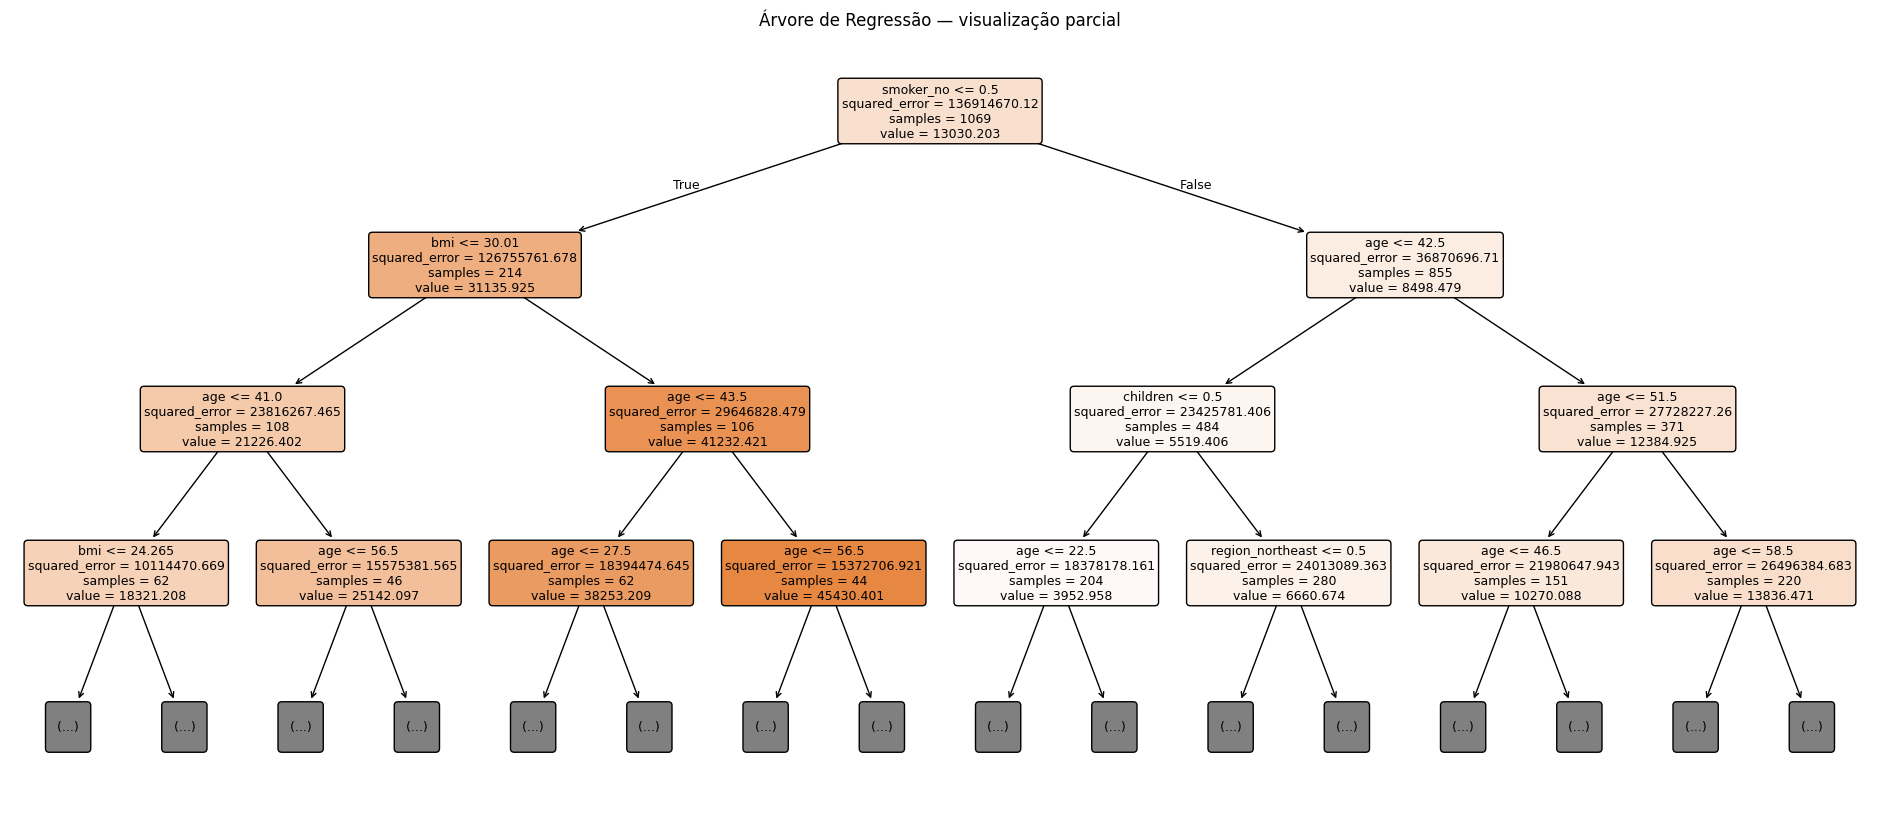

In [21]:
plt.figure(figsize=(24, 10))
plot_tree(
    modelo_arvore_treinado,
    feature_names=nomes_features,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Árvore de Regressão — visualização parcial")
plt.show()

**Interpretação:**

A raiz da árvore tende a separar segurados por `smoker`. Depois, dentro dos grupos, atributos como `bmi` e `age` ajudam a refinar a estimativa do valor do seguro.

## 2.17 Comparação visual dos modelos

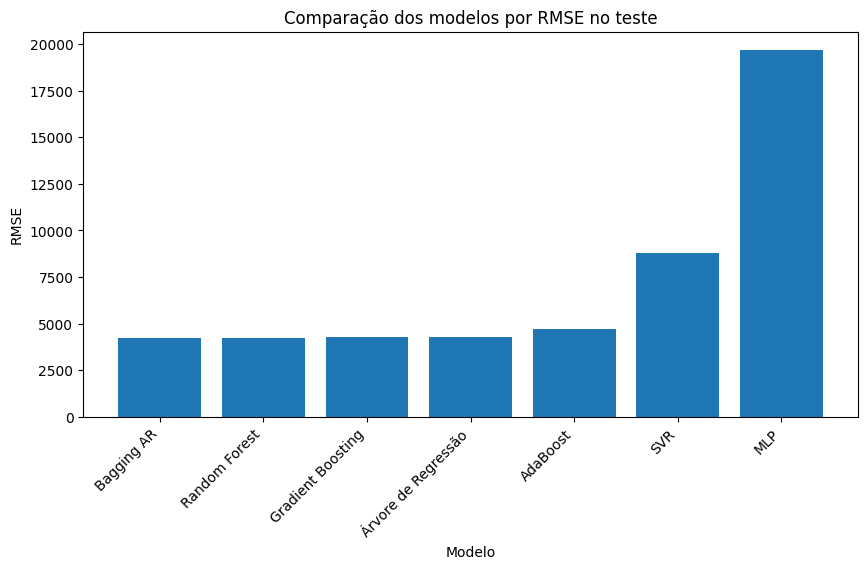

In [22]:
plt.figure(figsize=(10, 5))
plt.bar(resultados_df["Modelo"], resultados_df["RMSE_teste"])
plt.title("Comparação dos modelos por RMSE no teste")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.show()

**Interpretação:**

Quanto menor o RMSE, melhor o modelo. O ensemble `Gradient Boosting` tende a apresentar o menor RMSE, mas a Árvore de Regressão segue competitiva e é mais interpretável.

## 2.18 Gráfico: valores reais vs. valores preditos pela Árvore de Regressão

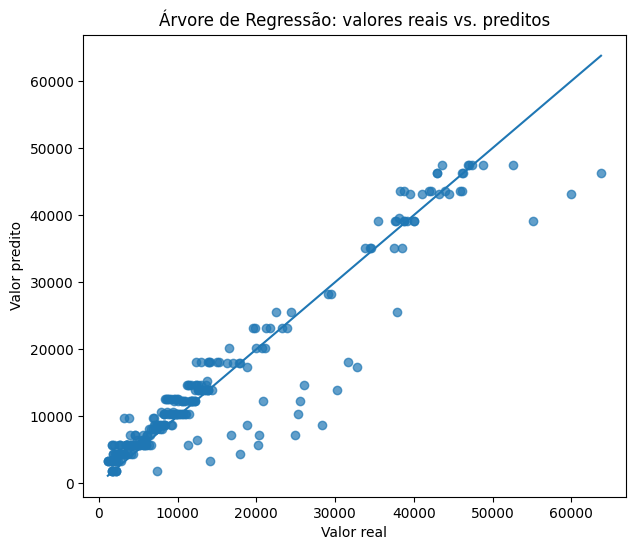

In [23]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_ar, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Árvore de Regressão: valores reais vs. preditos")
plt.xlabel("Valor real")
plt.ylabel("Valor predito")
plt.show()

## 2.19 Análise dos resíduos

Diferença entre o valor real e o valor predito:

\[
resíduo = y - \hat{y}
\]

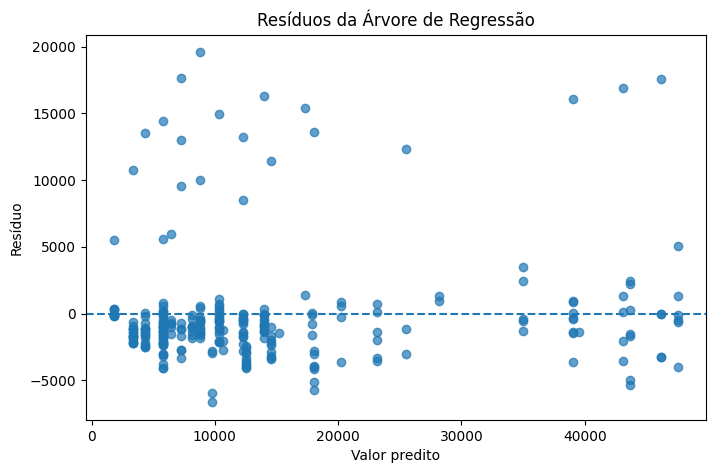

In [24]:
residuos_ar = y_test - y_pred_ar

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_ar, residuos_ar, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Resíduos da Árvore de Regressão")
plt.xlabel("Valor predito")
plt.ylabel("Resíduo")
plt.show()

**Interpretação:**

Os erros muito altos, geralmente, estarão associados a segurados com valores de seguro muito elevados.

# 3) Interpretação

A Árvore de Regressão obteve desempenho aproximado de:

- **MAE:** 2503.30;
- **RMSE:** 4302.95;
- **R²:** 0.8992.

Isso significa que o modelo explica aproximadamente **89% da variação** do valor do seguro no conjunto de teste.

O melhor desempenho geral foi obtido pelo **Bagging AR**, com RMSE de aproximadamente 4204,24 e R² de 0,9038 no conjunto de teste. Isso indica que o modelo conseguiu explicar cerca de 90,38% da variação observada no valor do seguro saúde.  

Assim, a conclusão é: o **Bagging AR** foi o melhor modelo preditivo geral, enquanto a **Árvore de Regressão** é o modelo mais adequado para apresentação explicável.  

A análise de importância dos atributos mostra que os fatores mais relevantes para estimar `charges` são:

1. `smoker`;
2. `bmi`;
3. `age`;
4. `children`, com menor contribuição.

A variável `region` e a variável `sex` podem ter pouca importância na Árvore de Regressão ajustada neste experimento.

Em termos práticos, a Árvore de Regressão atende bem ao requisito de explicabilidade: ela permite mostrar as regras usadas para chegar ao valor estimado do seguro.

# 4) Resposta final

O exercício foi resolvido como um problema de **regressão supervisionada**, tendo `charges` como atributo alvo e `age`, `sex`, `bmi`, `children`, `smoker` e `region` como atributos de entrada.

Como a base possui atributos categóricos, as variáveis `sex`, `smoker` e `region` foram transformadas com **One-Hot Encoding**. Para os modelos sensíveis à escala, como SVR e MLP, também foi aplicado `StandardScaler` nas variáveis numéricas.

O modelo principal foi uma **Árvore de Regressão**, escolhida por ser caixa branca e facilmente explicável.

A variável mais importante para estimar o valor do seguro foi `smoker`, seguida por `bmi` e `age`. Portanto, o modelo sugere que o status de fumante, o índice de massa corporal e a idade são os principais fatores associados à variação no valor do seguro saúde.